In [1]:
import os
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

feat_ext = '-ch3sk1fk1fl1_ch3_nucleus_areas.npy'
seg_ext = '-ch2sk1fk1fl1_ch2_nucleu_mask.png'
csv_ext = '-ch2sk1fk1fl1.tiff_cell_count.csv'

class CellPaintBase(Dataset):
    def __init__(self, root_directory, feat_type='pixel_average', transform=None):
        """
        Args:
            root_directory (str): Root path to the cell paint data.
            dosage_directory (dict): A mapping from directory names to dosage values.
            transform (callable, optional): Optional transform to be applied on the image.
        """
        self.root_directory = root_directory
        self.transform = transform
        
        # List to store each record as a dictionary
        self.data = []
        
        # Walk through the directory structure and gather file paths
        for root, _, files in os.walk(root_directory):
            for file in files:
                name, ext = os.path.splitext(file)
                self.feat_type = feat_type
                if not file.endswith('nucleus_areas.png'):
                    continue

                # Build file paths
                run_name = name[:12]


                
                feat_image_path = os.path.join(root, run_name + feat_ext)
                seg_image_path = os.path.join(root, run_name + seg_ext)
                csv_path = os.path.join(root, run_name+csv_ext)
                # csv_path = os.path.join(root, name + '_cell_count.csv')
                # csv_data_path = os.path.join(root, name + '_data.csv')
                
                # Create a record dictionary
                record = {
                    'feat_image_path': feat_image_path,
                    'run_name': run_name,
                    'seg_image_path': seg_image_path, 
                    'csv_path': csv_path,
                }
                
                # Load the CSV file to get the cell count (assumes the count is in the first row)
                try:
                    df = pd.read_csv(csv_path)
                    record['cell_count'] = df['cell_count'][0]
                except Exception as e:
                    print(f"Error reading CSV file {csv_path}: {e}")
                    continue  # Skip this record if there's an issue reading the CSV
                
                # Determine dosage by checking directory names in the relative path
                
                
                self.data.append(record)
    
    def __len__(self):
        return len(self.data)
    
    def feat_func(self, record, type='rpe_images'):

        if type == 'pixel_average':
            img_array = np.load(record['feat_image_path'])

            feature = img_array[img_array>0].mean()
        else:
            raise NotImplementedError()
        
        return feature
    
    def __getitem__(self, idx):
        record = self.data[idx]
        # Load image using PIL and convert to RGB
        # image = Image.open(record['image']).convert('RGB')
        # r, g, b = image.split()
        # g_np = np.array(g)
        # # if self.transform:
        #     image = self.transform(image)
        
        # feature = self.feat_func(record, self.feat_type)
        
        sample = record
        # sample['feature'] = feature
        
        return sample


#maximize over p value, run_name is r, c, f values

In [2]:
root_directory = "/hpcgpfs01/scratch/xyu1/ch2_3_new"
feat_type = 'pixel_average' 

# Example transform using torchvision
from torchvision import transforms
# transform = transforms.Compose([
# transforms.Resize((256, 256)),
# transforms.ToTensor()
# ])

dataset = CellPaintBase(root_directory=root_directory, feat_type=feat_type)

# Access and inspect a sample
sample = dataset[0]
# print('feature', sample['feature'])
print("feat_image_path:", sample['feat_image_path'])
print("run_name:", sample['run_name'])
#print("CSV data path:", sample['csv_data'])

feat_image_path: /hpcgpfs01/scratch/xyu1/ch2_3_new/r08c12f04p10-ch3sk1fk1fl1_ch3_nucleus_areas.npy
run_name: r08c12f04p10


In [4]:
image_list = {}

for i in range(len(dataset)):
    image_record = dataset[i]
    image_list[image_record['run_name']] = image_record
    #sample_list.append(dataset[i])
image_list = dict(sorted(image_list.items()))

In [15]:
from collections import defaultdict
sample_list = defaultdict(dict)

for k in image_list.keys():
    prefix = k[:9]
    sample_list[prefix].setdefault('list', []).append(k)



In [16]:
def feat_func(sample, type='rpe_images'):
#sample = sample_list['r01c01f01']

    if type == 'depth_maximize_pixel_avg':
        img_list = []
        for image_key in sample['list']:
            record = image_list[image_key]
            img_array = np.load(record['feat_image_path'])
            img_list.append(img_array)

        stacked = np.stack(img_list)
        max_image = np.max(stacked, axis=0)
        
        feature = max_image[max_image>0].mean()

    return feature

In [17]:
type = 'depth_maximize_pixel_avg'
for key in sample_list:
    sample = sample_list[key]
    feature = feat_func(sample, type)
    sample['feature'] = feature

In [18]:
from matplotlib import pyplot as plt
plt.imshow(max_image, vmin=0, vmax = 10000)

NameError: name 'max_image' is not defined

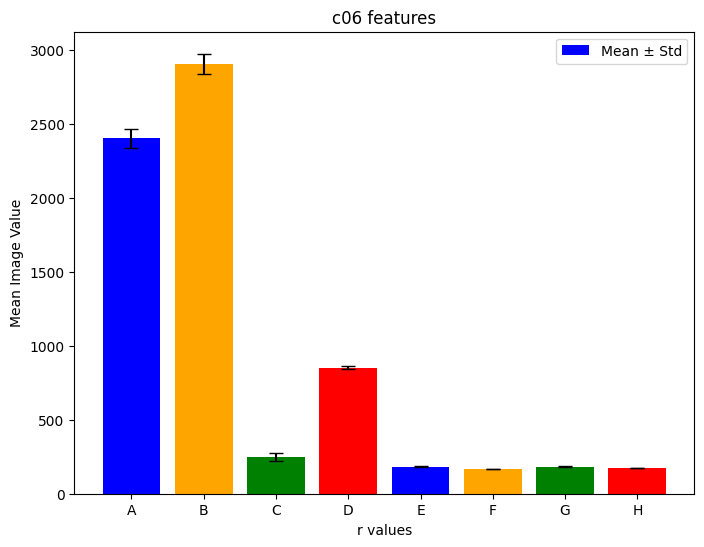

In [21]:
# Initialize a dictionary to store the means of the images for each r
image_means_by_r = {}
c = '06'
# Iterate through the values of r
for r in ['01', '02', '03', '04', '05', '06', '07', '08']:
    image_means = []  # Initialize a list to store the means for the current r
    
    # Iterate through the values of f
    for f in range(1, 10):  # f takes values from '01' to '09'
        # Iterate through the images
        for p in ['01']:  # Assuming there are 5 images (p01 to p05)
            # Load the TIFF image
            run_name = f'r{r}c{c}f{f:02d}'
            if run_name in sample_list:
                feature = sample_list[run_name]['feature']
                image_means.append(feature)
            else:
                # print('no', run_name)
                pass
    
    # Store the means for the current r
    image_means_by_r[r] = image_means

# Calculate the mean and standard deviation for each r
mean_std_by_r = {r: (np.mean(means), np.std(means)) for r, means in image_means_by_r.items()}

# Plot the mean and standard deviation for each r
labels = list(mean_std_by_r.keys())

means = [mean_std_by_r[r][0] for r in labels]
stds = [mean_std_by_r[r][1] for r in labels]
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
x = range(len(labels))  # X-axis positions


plt.figure(figsize=(8, 6))
plt.bar(x, means, yerr=stds, capsize=5, color=['blue', 'orange', 'green', 'red'])
plt.xticks(x, labels)
plt.xlabel('r values')
plt.ylabel('Mean Image Value')
plt.title(f'c{c} features')
plt.legend(['Mean ± Std'])
plt.show()

In [7]:
image_list['r01c01f01p01']

{'feat_image_path': '/hpcgpfs01/scratch/xyu1/ch2_3_new/r01c01f01p01-ch3sk1fk1fl1_ch3_nucleus_areas.npy',
 'run_name': 'r01c01f01p01',
 'seg_image_path': '/hpcgpfs01/scratch/xyu1/ch2_3_new/r01c01f01p01-ch2sk1fk1fl1_ch2_nucleu_mask.png',
 'csv_path': '/hpcgpfs01/scratch/xyu1/ch2_3_new/r01c01f01p01-ch2sk1fk1fl1.tiff_cell_count.csv',
 'cell_count': 153}

In [ ]:
## image list result cell count

# Initialize a dictionary to store the means of the images for each r
image_means_by_r = {}
c = '12'
# Iterate through the values of r
for r in ['01', '02', '03', '04', '05', '06', '07', '08']:
    image_means = []  # Initialize a list to store the means for the current r
    
    # Iterate through the values of f
    for f in range(1, 10):  # f takes values from '01' to '09'
        # Iterate through the images
        for p in ['01']:  # Assuming there are 5 images (p01 to p05)
            # Load the TIFF image
            run_name = f'r{r}c{c}f{f:02d}'
            if run_name in sample_list:
                feature = sample_list[run_name]['feature']
                image_means.append(feature)
            else:
                # print('no', run_name)
                pass
    
    # Store the means for the current r
    image_means_by_r[r] = image_means

# Calculate the mean and standard deviation for each r
mean_std_by_r = {r: (np.mean(means), np.std(means)) for r, means in image_means_by_r.items()}

# Plot the mean and standard deviation for each r
labels = list(mean_std_by_r.keys())
means = [mean_std_by_r[r][0] for r in labels]
stds = [mean_std_by_r[r][1] for r in labels]

x = range(len(labels))  # X-axis positions

plt.figure(figsize=(8, 6))
plt.bar(x, means, yerr=stds, capsize=5, color=['blue', 'orange', 'green', 'red'])
plt.xticks(x, labels)
plt.xlabel('r values')
plt.ylabel('Mean Image Value')
plt.title(f'c{c} features')
plt.legend(['Mean ± Std'])
plt.show()

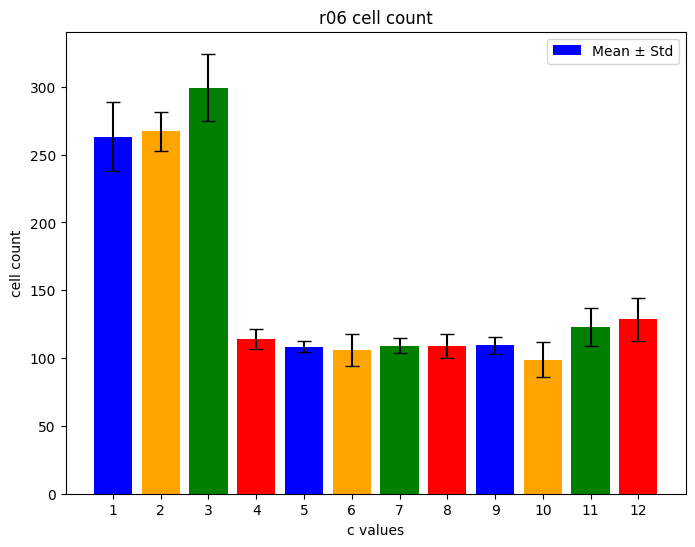

In [22]:
# Initialize a dictionary to store the means of the images for each r

from matplotlib import pyplot as plt
image_means_by_c = {}
r = '06'
# Iterate through the values of r
for c in range(1, 13):
    image_means = []  # Initialize a list to store the means for the current r
    
    # Iterate through the values of f
    for f in range(1, 10):  # f takes values from '01' to '09'
        # Iterate through the images
        for p in range(1, 16):  # Assuming there are 5 images (p01 to p05)
            # Load the TIFF image
            run_name = f'r{r}c{c:02d}f{f:02d}p{p:02d}'
            if run_name in image_list:
                cell_count = image_list[run_name]['cell_count']
                image_means.append(cell_count)
            else:
                # print('no', run_name)
                pass
    
    # Store the means for the current r
    image_means_by_c[c] = image_means

# Calculate the mean and standard deviation for each r
mean_std_by_c = {c: (np.mean(means), np.std(means)) for c, means in image_means_by_c.items()}

# Plot the mean and standard deviation for each r
labels = list(mean_std_by_c.keys())
means = [mean_std_by_c[c][0] for c in labels]
stds = [mean_std_by_c[c][1] for c in labels]

x = range(len(labels))  # X-axis positions

plt.figure(figsize=(8, 6))
plt.bar(x, means, yerr=stds, capsize=5, color=['blue', 'orange', 'green', 'red'])
plt.xticks(x, labels)
plt.xlabel('c values')
plt.ylabel('cell count')
plt.title(f'r{r} cell count')
plt.legend(['Mean ± Std'])
plt.show()